In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [45]:
from sklearn.datasets import make_blobs

In [46]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/personnel_data.csv')
df.head(3)

,EmployeeID,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
0,1,50,1,2,33.07,3,5,10,0
1,2,36,4,1,19.37,7,1,11,0
2,3,29,28,1,52.64,8,1,5,1


In [47]:
data = make_blobs(n_samples = 200, n_features = 2, centers = 4, cluster_std = 1.8, random_state = 101)

In [48]:
data[0].shape

(200, 2)

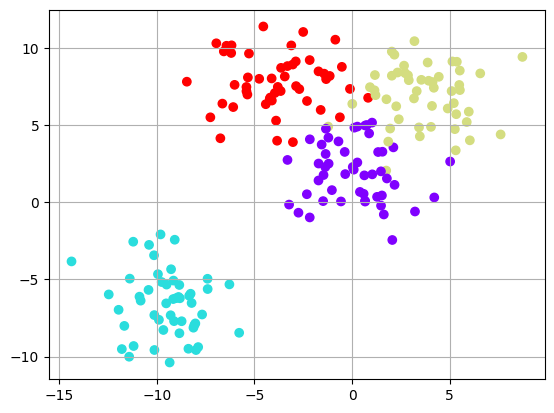

In [49]:
plt.scatter(data[0][:,0], data[0][:,1], c = data[1], cmap = 'rainbow') # Plotting column 1 and column 2
plt.grid()

In [50]:
from sklearn.cluster import KMeans

In [51]:
kmeans = KMeans(n_clusters = 2)

In [52]:
kmeans.fit(data[0])

KMeans(n_clusters=2)

In [53]:
kmeans.cluster_centers_ # centroid of clusters

array([[-0.0336134 ,  5.54542558],
       [-9.46941837, -6.56081545]])

In [54]:
kmeans.labels_

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0], dtype=int32)

In [55]:
data[1]

array([3, 2, 0, 2, 2, 1, 2, 0, 2, 0, 3, 0, 2, 2, 3, 0, 2, 0, 1, 3, 1, 0,
       0, 1, 3, 1, 1, 0, 2, 2, 3, 1, 2, 0, 0, 3, 1, 1, 1, 2, 1, 3, 3, 3,
       0, 3, 3, 0, 1, 2, 0, 3, 2, 0, 1, 3, 0, 0, 3, 2, 1, 2, 1, 3, 2, 0,
       1, 2, 2, 1, 2, 0, 1, 3, 1, 2, 2, 0, 3, 0, 0, 1, 2, 1, 0, 0, 0, 3,
       2, 1, 1, 1, 1, 3, 0, 1, 2, 3, 1, 2, 0, 1, 0, 0, 2, 0, 1, 2, 1, 1,
       0, 3, 3, 2, 1, 2, 3, 3, 2, 3, 0, 3, 0, 3, 0, 2, 3, 0, 1, 3, 3, 3,
       0, 1, 1, 3, 2, 3, 2, 0, 1, 2, 1, 3, 3, 2, 0, 1, 3, 3, 3, 3, 0, 2,
       0, 3, 2, 2, 2, 0, 2, 0, 0, 3, 1, 3, 0, 2, 3, 0, 2, 0, 3, 3, 0, 3,
       2, 2, 1, 2, 3, 1, 1, 3, 1, 1, 1, 1, 1, 0, 1, 2, 2, 3, 1, 0, 2, 2,
       1, 0])

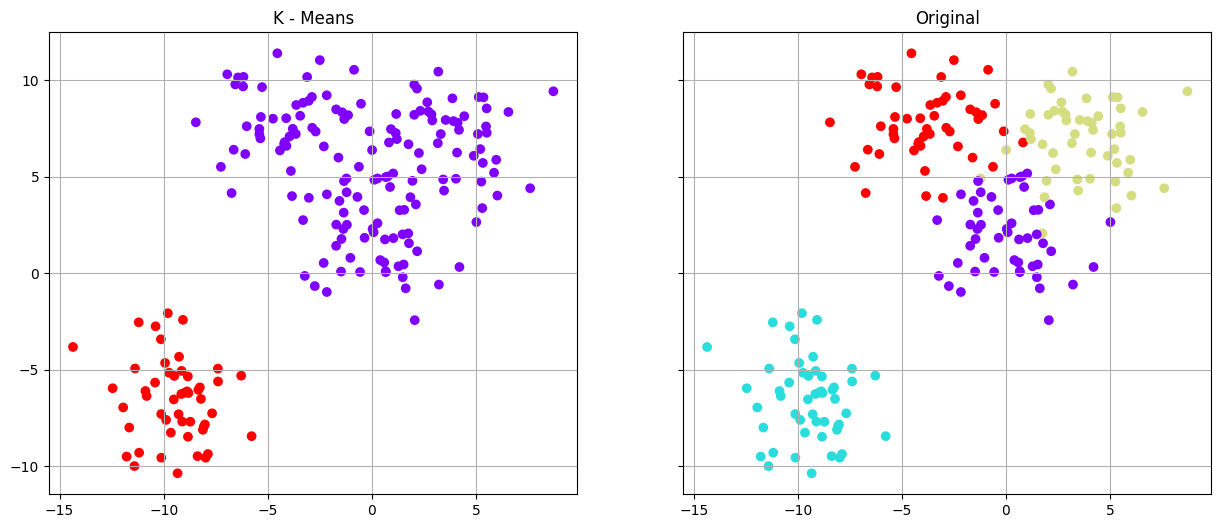

In [56]:
fig, (ax1, ax2) = plt.subplots(1,2, sharey = True, figsize = (15,6))

ax1.set_title('K - Means')
ax1.scatter(data[0][:,0], data[0][:,1], c = kmeans.labels_, cmap = 'rainbow')
ax1.grid()

ax2.set_title('Original')
ax2.scatter(data[0][:,0], data[0][:,1], c = data[1], cmap = 'rainbow')
ax2.grid()

In [57]:
df_cleaned = df.drop(['EmployeeID', 'PromotionLast5Years'], axis=1)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

In [59]:
#used random_state = 101, and n_init = 'auto' for KMeans
kmeans = KMeans(n_clusters=2, random_state=101, n_init='auto')
kmeans.fit(scaled_data)

KMeans(n_clusters=2, random_state=101)

In [60]:
# Calculate the correlation matrix
correlation_matrix = df_cleaned.corr()

# Set the correlation threshold
threshold = 0.66

In [61]:
# Identify highly correlated pairs (absolute value greater than threshold)
highly_correlated_pairs = {}
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname_i = correlation_matrix.columns[i]
            colname_j = correlation_matrix.columns[j]
            highly_correlated_pairs[(colname_i, colname_j)] = correlation_matrix.iloc[i, j]

variables_to_eliminate = set()
for (var1, var2), correlation in highly_correlated_pairs.items():
    # Eliminate the variable that comes first alphabetically
    if var1 < var2:
        variables_to_eliminate.add(var1)
    else:
        variables_to_eliminate.add(var2)

In [62]:
print("Highly correlated pairs (absolute correlation > 0.66):")
for (var1, var2), correlation in highly_correlated_pairs.items():
    print(f"{var1} and {var2}: {correlation:.2f}")

print("\nVariable(s) to be eliminated based on alphabetical order:")
for var in sorted(list(variables_to_eliminate)):
    print(var)

Highly correlated pairs (absolute correlation > 0.66):
Salary and Experience: 0.69

Variable(s) to be eliminated based on alphabetical order:
Experience


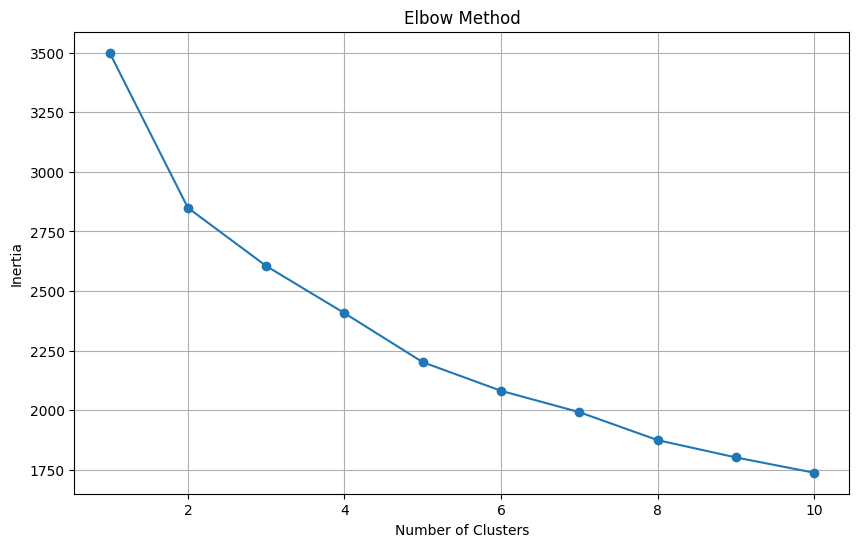

In [63]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=101, n_init='auto')
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In [64]:
# Optimal number of clusters identified from the Elbow method plot is 2.
kmeans = KMeans(n_clusters=2, random_state=101, n_init='auto')
kmeans.fit(scaled_data)

KMeans(n_clusters=2, random_state=101)

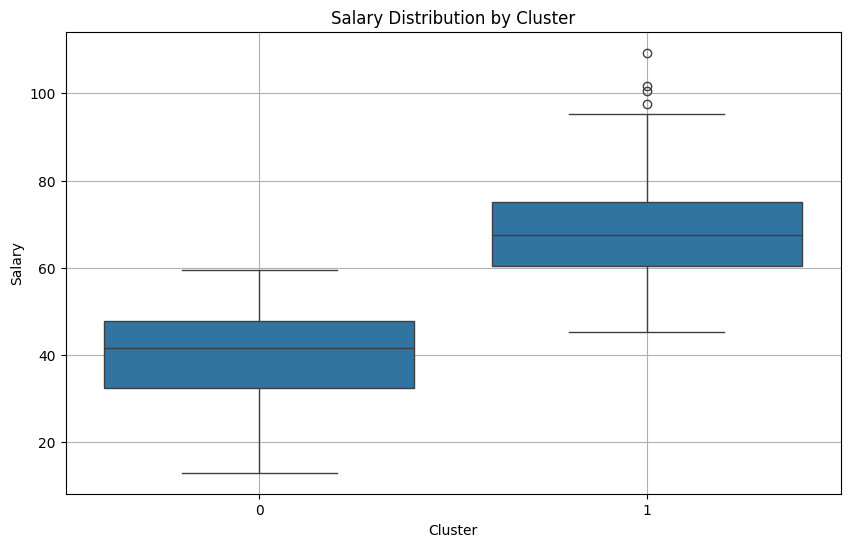

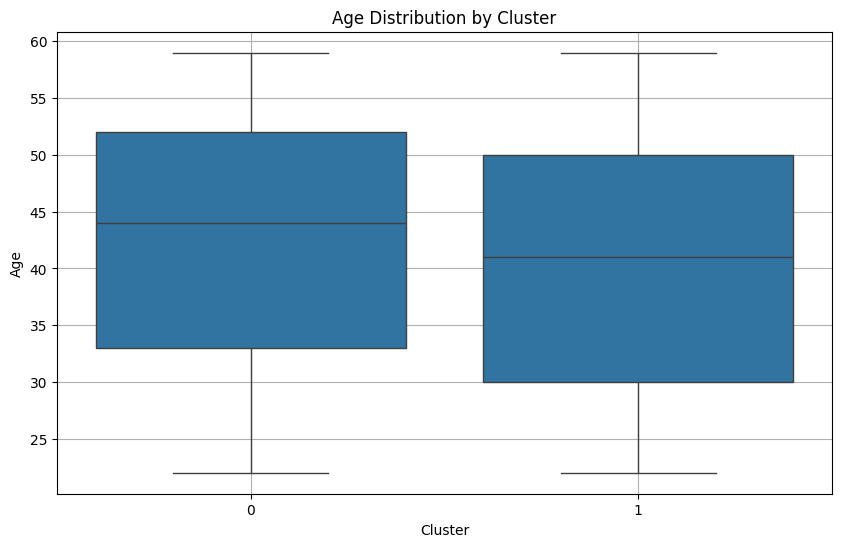

In [65]:
# Create a new DataFrame with cluster labels
df_clustered = df_cleaned.copy()
df_clustered['Cluster'] = kmeans.labels_

# Use seaborn.boxplot to create a boxplot of 'Salary' vs. the cluster labels
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Salary', data=df_clustered)
plt.title('Salary Distribution by Cluster')
plt.grid()
plt.show()

# Use seaborn.boxplot to create a boxplot of 'Age' vs. the cluster labels
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Age', data=df_clustered)
plt.title('Age Distribution by Cluster')
plt.grid()
plt.show()

In [66]:
cluster_305 = kmeans.labels_[305]
print(f"Data point 305 belongs to cluster: {cluster_305}")

Data point 305 belongs to cluster: 0


In [67]:
age_col_index = df_cleaned.columns.get_loc('Age')
salary_col_index = df_cleaned.columns.get_loc('Salary')

centroids = kmeans.cluster_centers_

age_centroids = centroids[:, age_col_index]
salary_centroids = centroids[:, salary_col_index]

print("Centroids for Age:")
print(age_centroids)
print("\nCentroids for Salary:")
print(salary_centroids)

Centroids for Age:
[ 0.07524311 -0.0919638 ]

Centroids for Salary:
[-0.73409992  0.89723324]


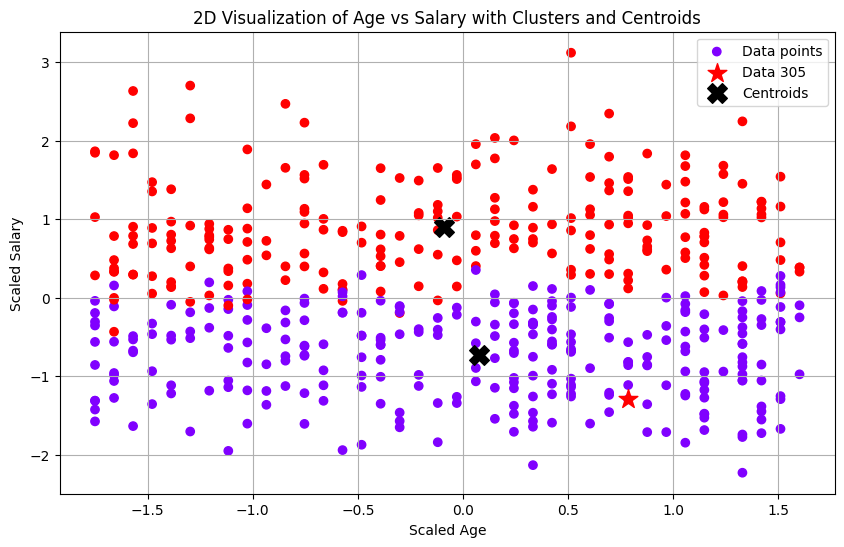

In [68]:
# a. Visualize the x = Age and y = Salary points, Show Data 305 with marker of star (*), color red, Show centroids with black (X) mark.
plt.figure(figsize=(10, 6))
plt.scatter(scaled_data[:, age_col_index], scaled_data[:, salary_col_index], c=kmeans.labels_, cmap='rainbow', label='Data points')
plt.scatter(scaled_data[305, age_col_index], scaled_data[305, salary_col_index], marker='*', color='red', s=200, label='Data 305')
plt.scatter(age_centroids, salary_centroids, marker='X', color='black', s=200, label='Centroids')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Salary')
plt.title('2D Visualization of Age vs Salary with Clusters and Centroids')
plt.legend()
plt.grid()
plt.show()